In [1]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any, Dict, List, Tuple

from comcatalyst.utils import calc_convergence_iter_bo

## **Functions.**

In [2]:
def load_results_from_json(json_path: str) -> List[dict]:
    return json.loads(Path(json_path).read_text())

def load_results_from_dir(dir_path: str) -> List[dict]:
    results = []
    for json_path in Path(dir_path).rglob("*.json"):
        data = load_results_from_json(json_path=json_path)
        results.extend(data)
    return results

In [3]:
def filter_results(results, filters):
    filtered = []
    for r in results:
        match = all(
            float(r["hyperparams"].get(k, None)) == float(v)
            if isinstance(v, (int, float))
            else str(r["hyperparams"].get(k)) == str(v)
            for k, v in filters.items()
        )
        if match:
            filtered.append(r)
    return filtered

In [4]:
def add_convergence_iter_bo_to_results(
    results: List[dict],
) -> List[dict]:
    for r in results:
        y_data = r["y_data"]
        n_init = r["hyperparams"]["n_init"]
        r["convergence_iter_bo"] = calc_convergence_iter_bo(y_data=y_data, n_init=n_init)
    return results

In [5]:
def plot_boxplot(
    results: List[dict],
    metric: str,
    group_by: str,
    filters: Dict[str, Any] = None,
    figsize: Tuple[int, int] = (7, 5),
    ylim: Tuple[float, float] = (None, None),
    title: str = None,
    save_path: str = None,
) -> None:

    if filters:
        results = filter_results(results, filters)

    if not results:
        print("No results found after filter was applied.")
        return
        
    # grouper par valeur de group_by
    groups = {}
    for r in results:
        val = r["hyperparams"].get(group_by)
        if val is None:
            continue
        key = str(val)
        if key not in groups:
            groups[key] = []
        groups[key].append(r[metric])

    # trier les groupes par valeur
    try:
        sorted_keys = sorted(groups.keys(), key=lambda x: float(x))
    except ValueError:
        sorted_keys = sorted(groups.keys())

    data   = [groups[k] for k in sorted_keys]
    labels = [f"{k}" for k in sorted_keys]
    #labels = [f"{k}\n(tot={len(groups[k])})" for k in sorted_keys]
    
    if title is None:
        filter_str = ", ".join(f"{k}={v}" for k, v in (filters or {}).items())
        title = f"{metric} by {group_by}" + (f" | {filter_str}" if filter_str else "")

    ylabel = metric

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(data, tick_labels=labels)

    for i, (key, d) in enumerate(zip(sorted_keys, data), start=1):
        median_val = np.median(d)
        mean_val = np.mean(d)
        min_val= np.min(d)
        max_val = np.max(d)

        ax.text(i, median_val, f"med={median_val:.3f}", ha="center", va="bottom", fontsize=7, color="orange")
        ax.text(i, mean_val, f"mean={mean_val:.3f}", ha="center", va="center", fontsize=7, color="blue")
        ax.text(i, min_val, f"{min_val:.3f}", ha="center", va="top", fontsize=7, color="black")
        ax.text(i, max_val, f"{max_val:.3f}", ha="center", va="bottom", fontsize=7, color="black")
    
    # true max
    if metric == "y_opt":
        ax.axhline(results[0]["y_true_max"], color="red", ls="--", lw=1)

    ax.set_xlabel(group_by)
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=ylim[0], top=ylim[1])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [6]:
def plot_convergence_curve(
    results: List[dict],
    metric: str,   
    filters: dict = None,
    figsize: tuple = (10, 5),
    ylim: Tuple[float, float] = (None, None),
    title: str = None,
    save_path: str = None,
) -> None:
    if filters:
        results = filter_results(results, filters)

    if not results:
        print("No results found after filter was applied.")
        return

    n_init = results[0]["hyperparams"]["n_init"]
    n_pts  = min(len(r["y_data"]) for r in results) # longueur minimale commune
    
    # pour chaque run, calculer la courbe
    all_curves = []
    for r in results:
        y = np.array(r["y_data"]).ravel()[:n_pts]
        y_best = np.maximum.accumulate(y) # meilleur y jusqu'a chaque iteration
        if metric == "y_best":
            all_curves.append(y_best)
        elif metric == "y_gap":
            y_true_max = r["y_true_max"]
            all_curves.append(np.abs(y_true_max - y_best))

    all_curves = np.array(all_curves) # shape (n_runs, n_pts)
    mean = all_curves.mean(axis=0)
    std = all_curves.std(axis=0)
    lo = all_curves.min(axis=0)
    hi = all_curves.max(axis=0)
    iters = np.arange(1, n_pts + 1)

    fig, ax = plt.subplots(figsize=figsize)

    # courbe par run en transparence
    for curve in all_curves:
        ax.plot(iters, curve, color="gray", lw=0.8, alpha=0.2)

    # mean
    ax.plot(iters, mean, color="blue", lw=2, label="mean")
    # std
    ax.fill_between(iters, mean - std, mean + std, alpha=0.2, color="blue", label="std")
    # min / max
    ax.fill_between(iters, lo, hi, alpha=0.1, color="blue", label="[min, max]")

    # separation DoE / BO
    ax.axvspan(1, n_init, alpha=0.07, color="orange", label="DoE")
    ax.axvspan(n_init, n_pts, alpha=0.07, color="green", label="BO")
    ax.axvline(n_init, color="black", ls="--", lw=1)

    # true max
    if metric == "y_best":
        ax.axhline(results[0]["y_true_max"], color="red", ls="--", lw=1)
    elif metric == "y_gap":
        ax.axhline(0, color="red", ls="--", lw=1)

    ax.set_xlabel("Nombre de points evalues")
    ax.set_ylabel(metric)
    ax.set_ylim(bottom=ylim[0], top=ylim[1])
    ax.set_title(title or f"{metric} vs iterations")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

## **Load results.**

In [20]:
res = load_results_from_dir("../data/xpr_moda_benchmark_021a")

In [21]:
print("Total runs:", len(res))
print("n_init values:", sorted(set(r["hyperparams"]["n_init"] for r in res)))
print("n_iter_bo values:", sorted(set(r["hyperparams"]["n_iter_bo"] for r in res)))
print("sigma_noise values:", sorted(set(r["hyperparams"]["sigma_noise"] for r in res)))
print("bo_criterion values:", sorted(set(r["hyperparams"]["bo_criterion"] for r in res)))
print("seeds:", sorted(set(r["seed"] for r in res)))

Total runs: 480
n_init values: [2, 6, 10, 14]
n_iter_bo values: [16, 20, 24, 28]
sigma_noise values: [0.1, 1.0]
bo_criterion values: ['EI', 'LCB']
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]


## **Plots.**

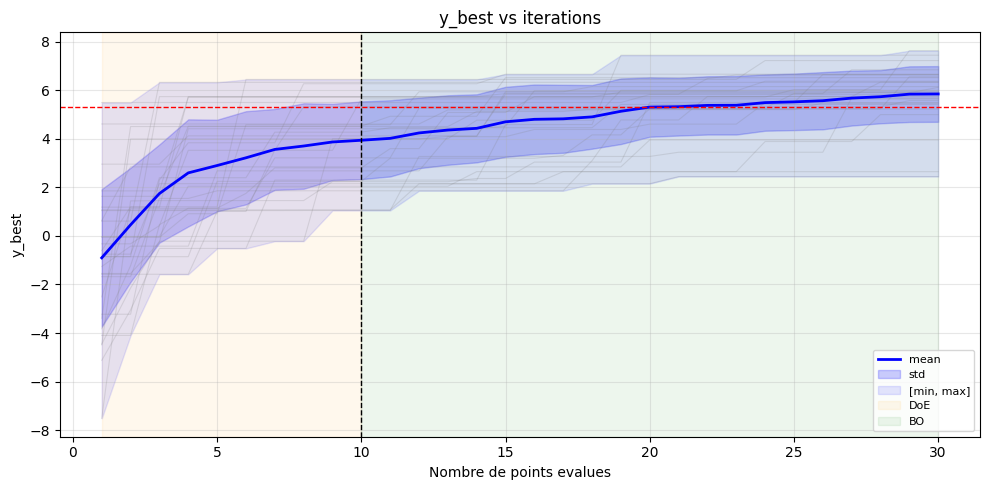

In [23]:
plot_convergence_curve(
    results  = res,
    filters  = {"n_init": 10, "bo_criterion": "EI", "sigma_noise": 1.0},
    metric   = "y_best",
)

### **Boxplots convergence_iter group by n_init.**

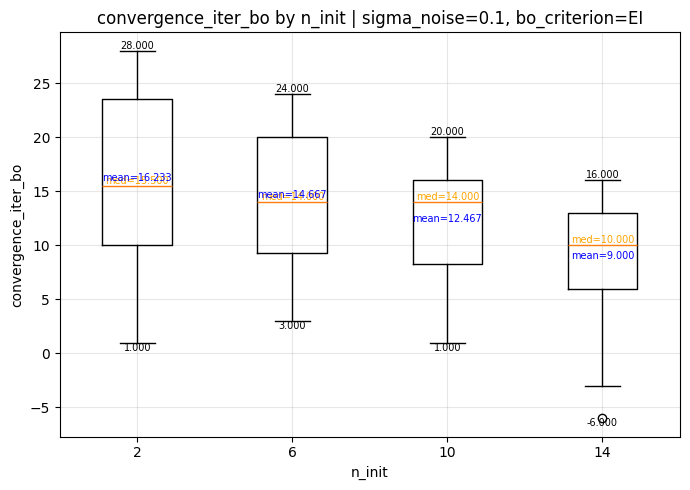

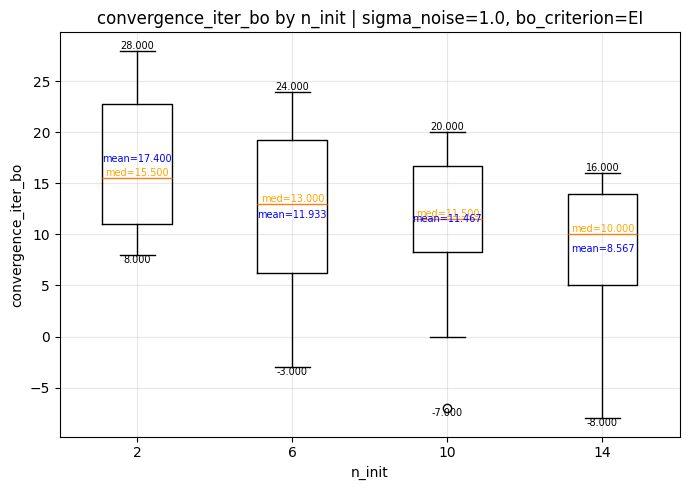

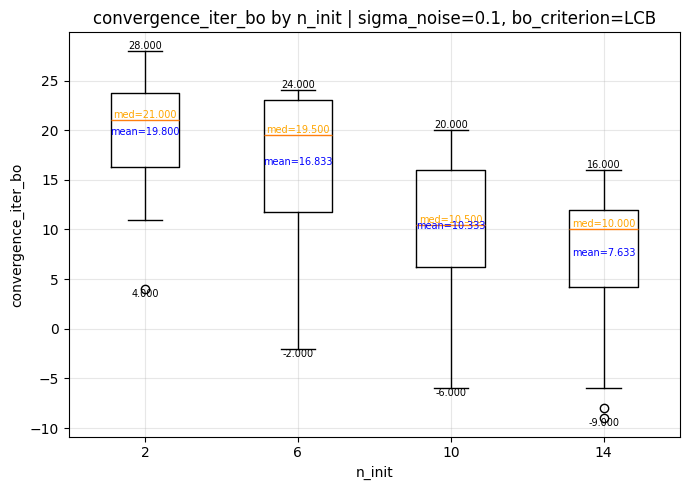

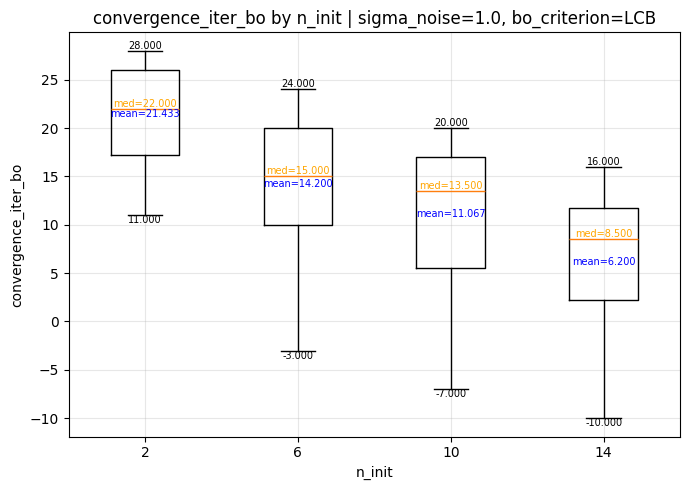

In [24]:
for bo_criterion in ["EI", "LCB"]:
        for sigma_noise in [0.1, 1.0]:
            plot_boxplot(
                results = res,
                metric    = "convergence_iter_bo",
                group_by  = "n_init",
                filters   = {
                    "sigma_noise": sigma_noise,
                    "bo_criterion": bo_criterion,
                },
            )

### **Boxplots x_gap group by n_init.**

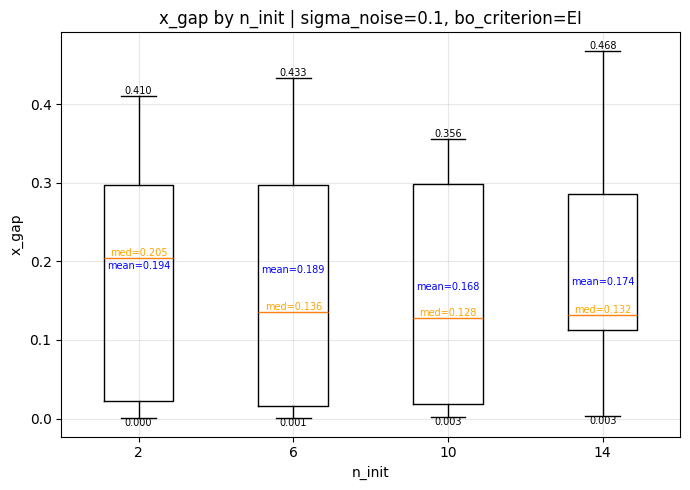

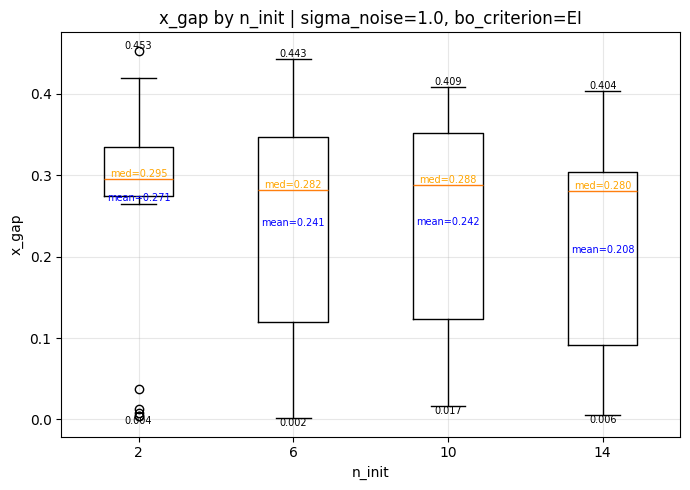

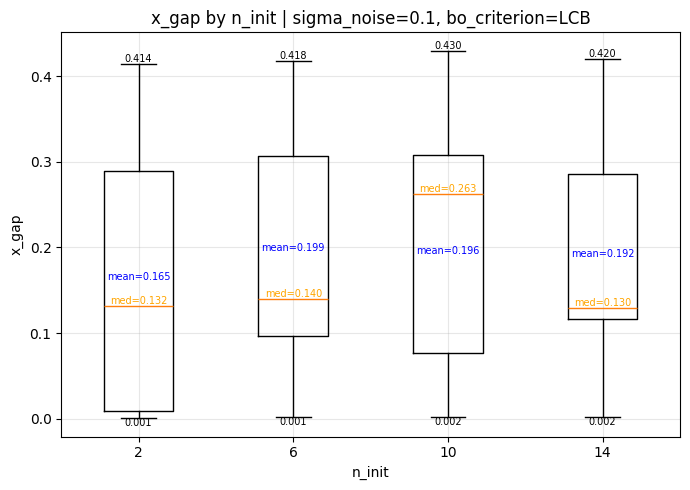

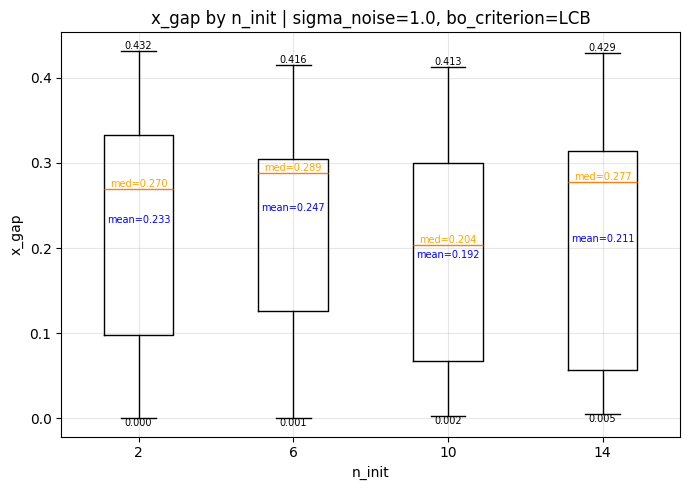

In [25]:
# x_gap group by n_init
for bo_criterion in ["EI", "LCB"]:
        for sigma_noise in [0.1, 1.0]:
            plot_boxplot(
                results = res,
                metric    = "x_gap",
                group_by  = "n_init",
                filters   = {
                    "sigma_noise": sigma_noise,
                    "bo_criterion": bo_criterion,
                },
            )

### **Boxplots y_gap group by n_init.**

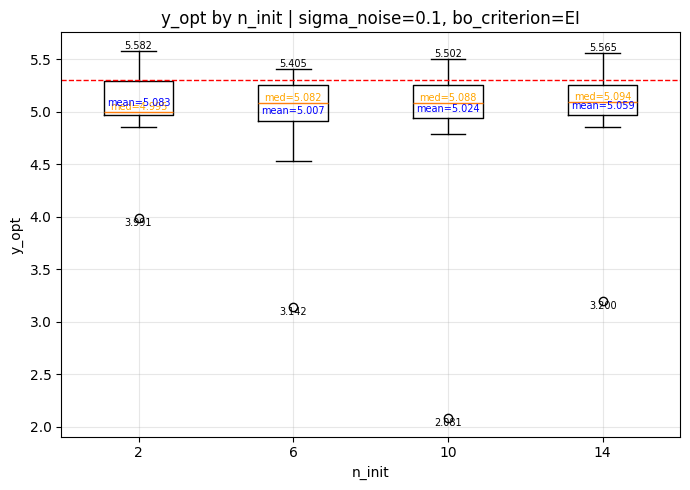

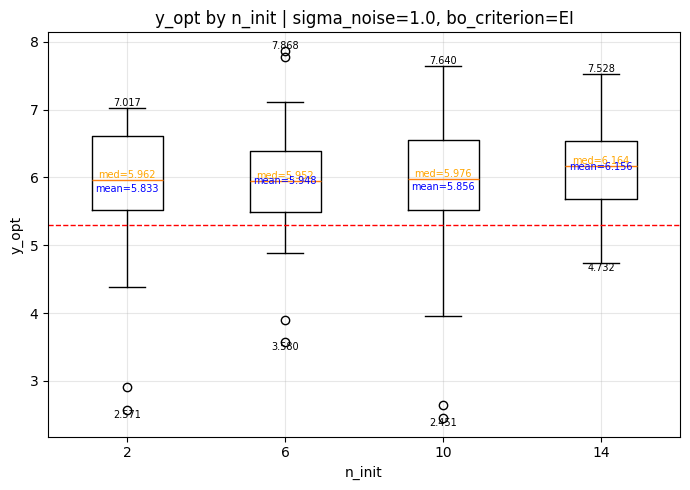

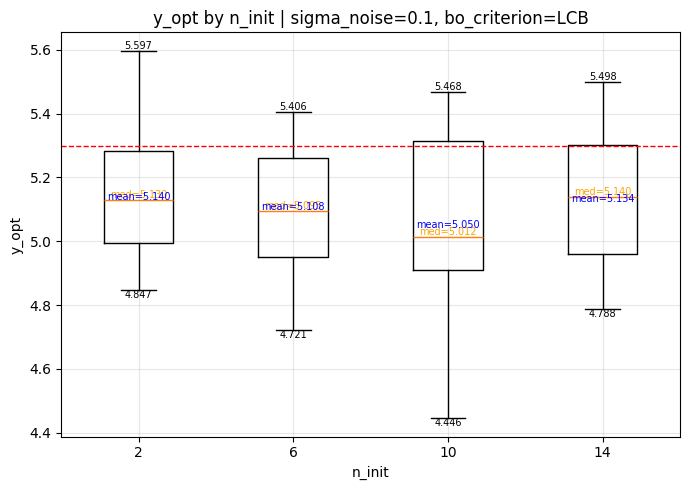

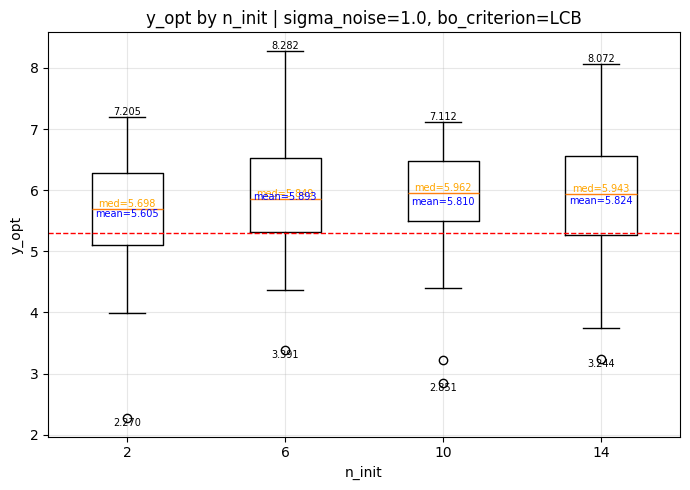

In [26]:
# y_gap group by n_init
for bo_criterion in ["EI", "LCB"]:
        for sigma_noise in [0.1, 1.0]:
            plot_boxplot(
                results = res,
                metric    = "y_opt",
                group_by  = "n_init",
                filters   = {
                    "sigma_noise": sigma_noise,
                    "bo_criterion": bo_criterion,
                },
            )

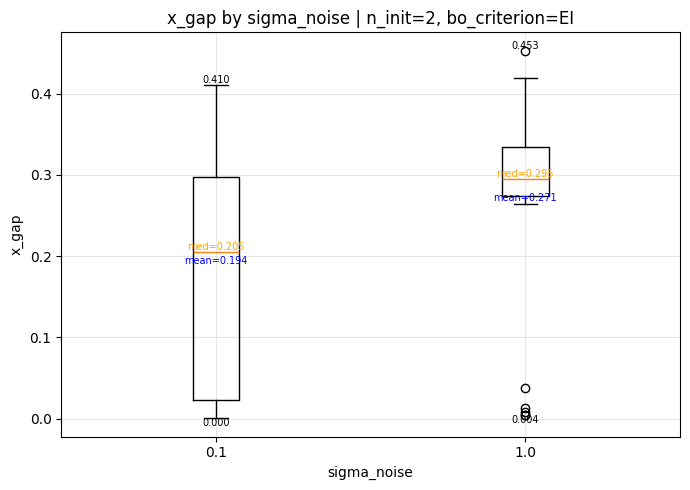

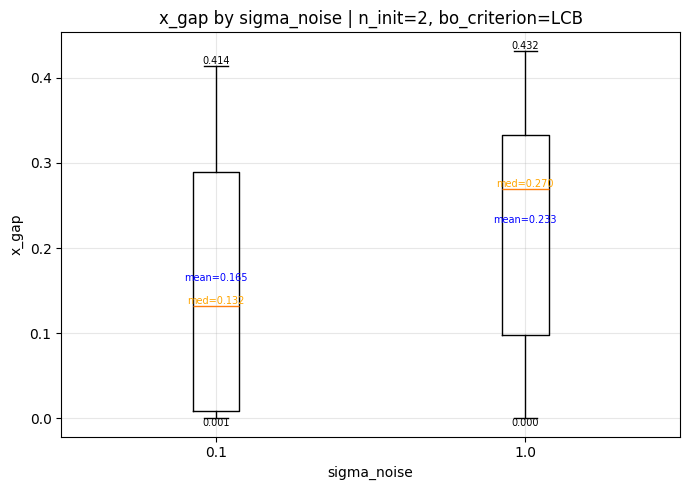

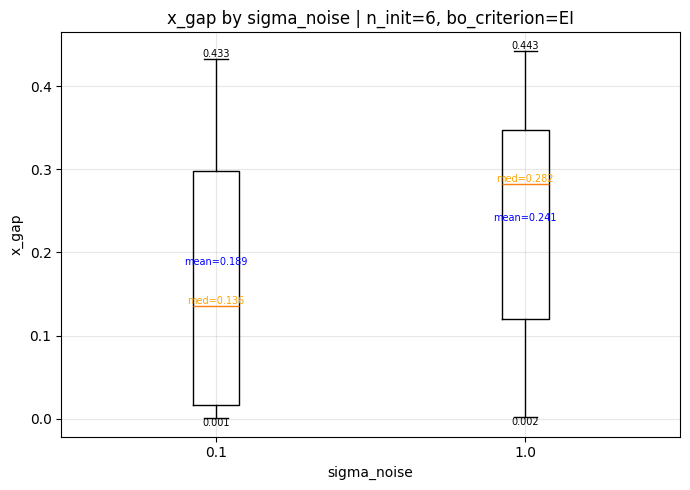

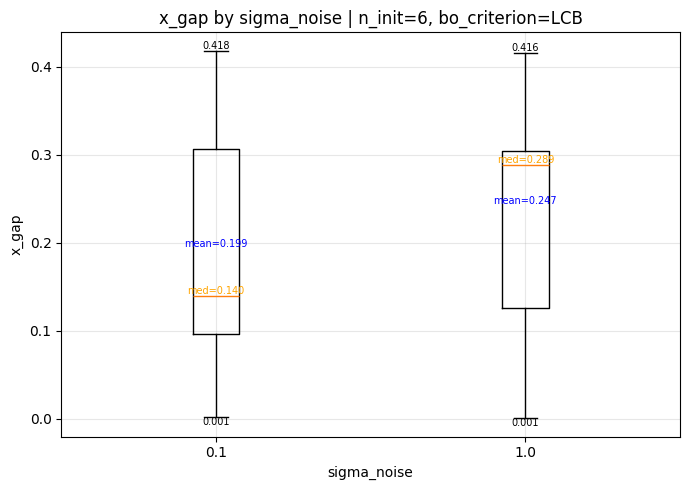

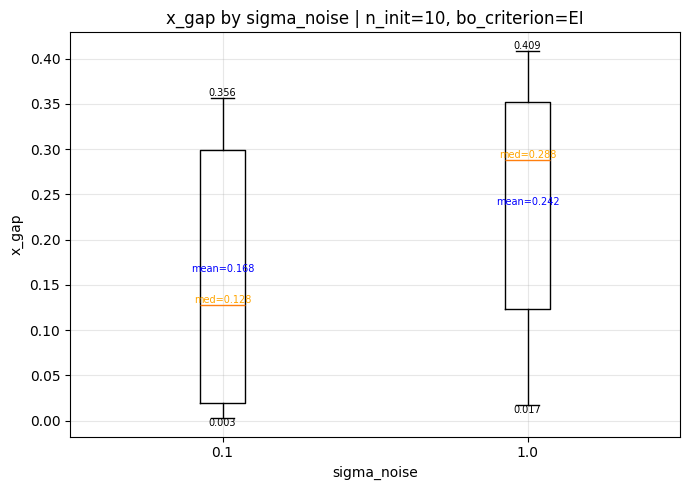

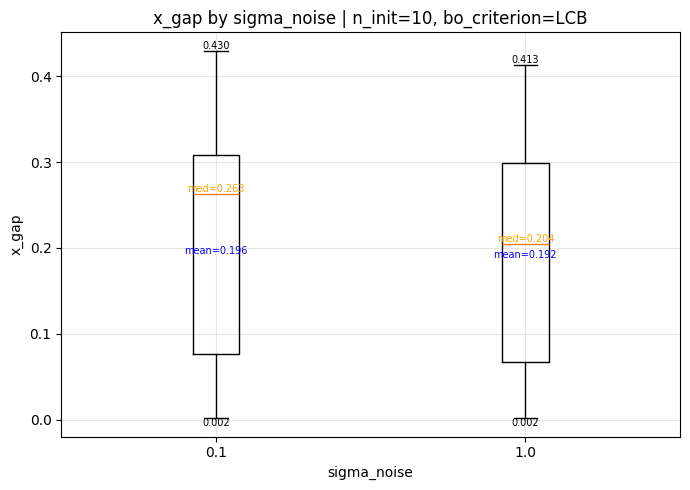

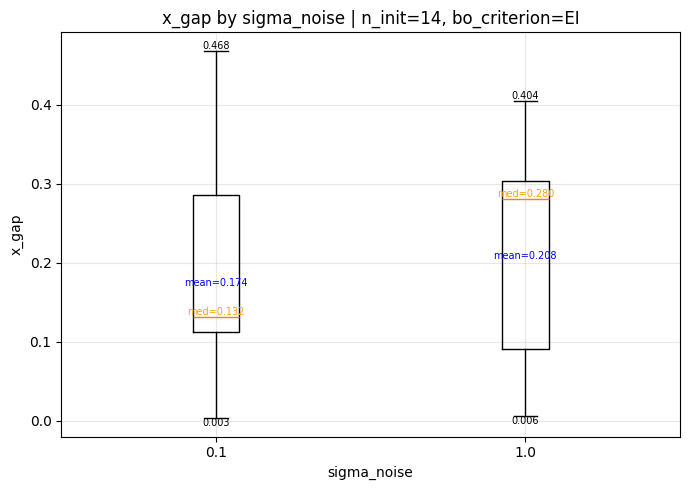

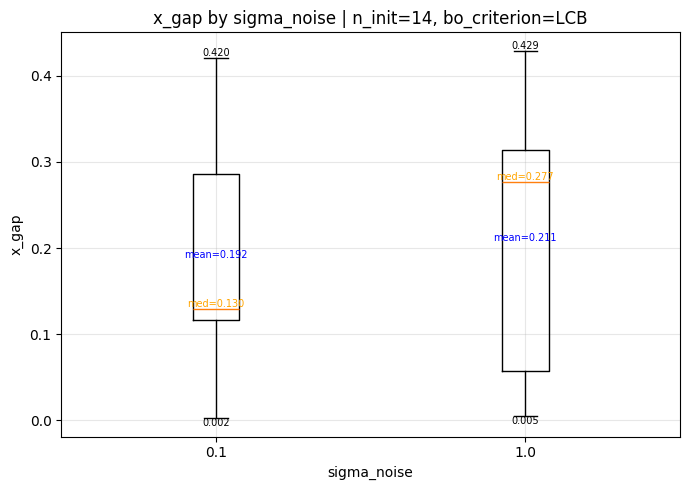

In [27]:
# x_gap group by sigma_noise
for n_init in [2, 6, 10, 14]:
    for bo_criterion in ["EI", "LCB"]:
            plot_boxplot(
                results = res,
                metric    = "x_gap",
                group_by  = "sigma_noise",
                filters   = {
                    "n_init": n_init,
                    "bo_criterion": bo_criterion
                },
            )

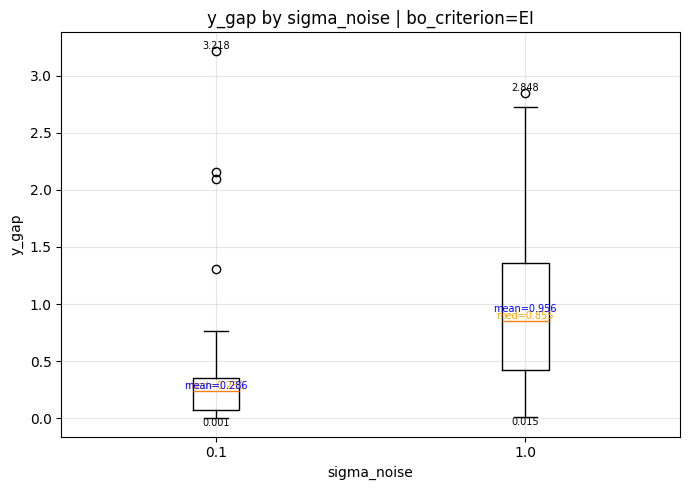

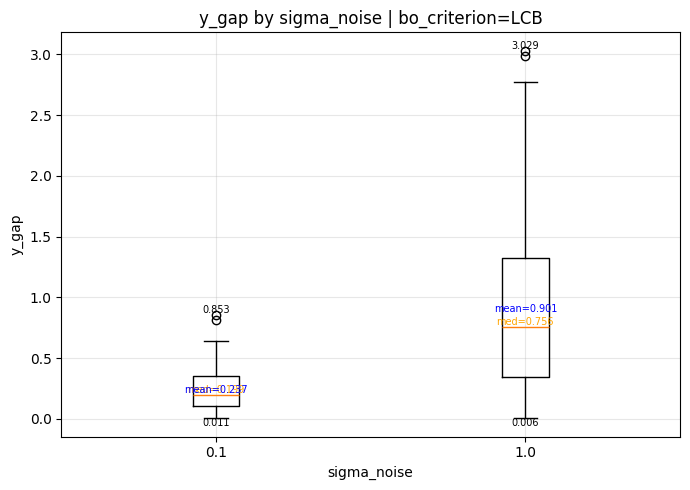

In [28]:
# y_gap group by sigma_noise
#for n_init in [2, 6, 10, 14]:
for bo_criterion in ["EI", "LCB"]:
    plot_boxplot(
        results = res,
        metric    = "y_gap",
        group_by  = "sigma_noise",
        filters   = {
           # "n_init": n_init,
            "bo_criterion": bo_criterion
        },
    )

### **Boxplots x_gap group by bo_criterion.**

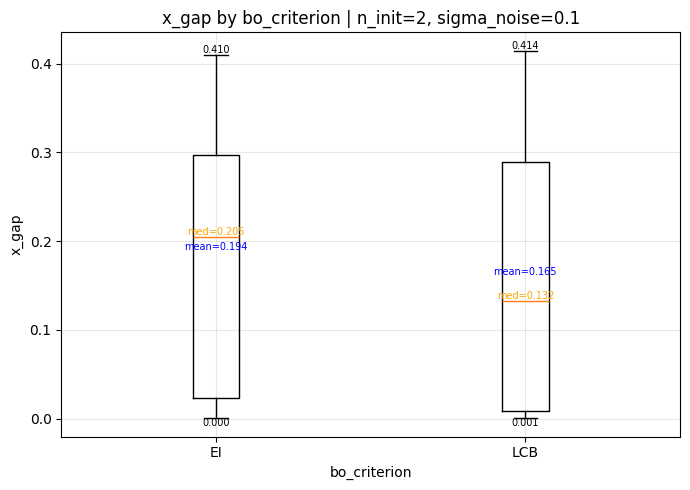

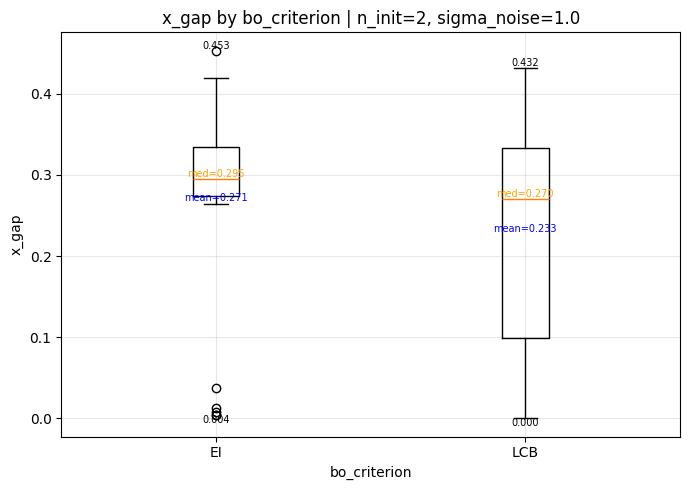

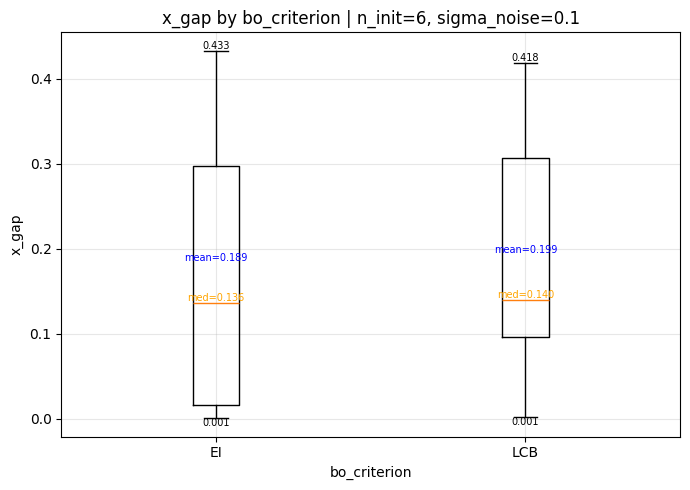

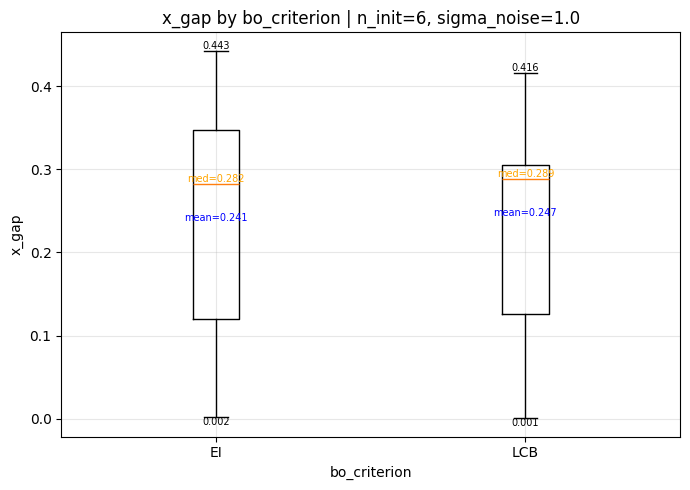

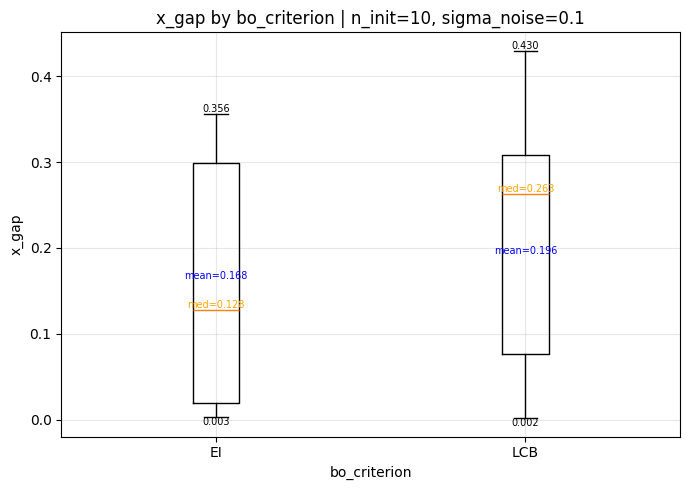

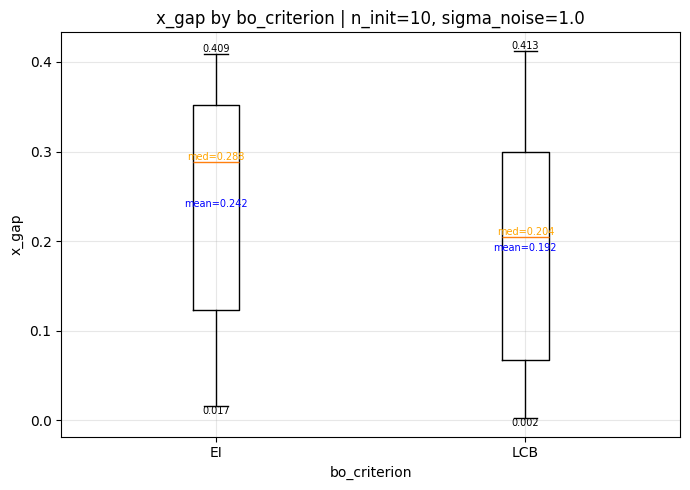

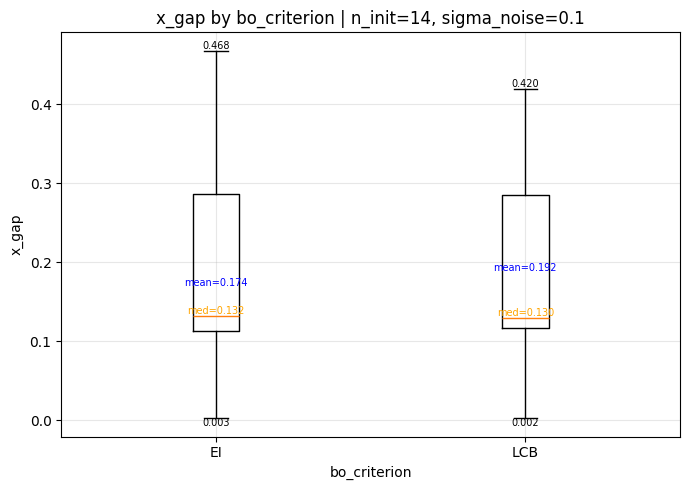

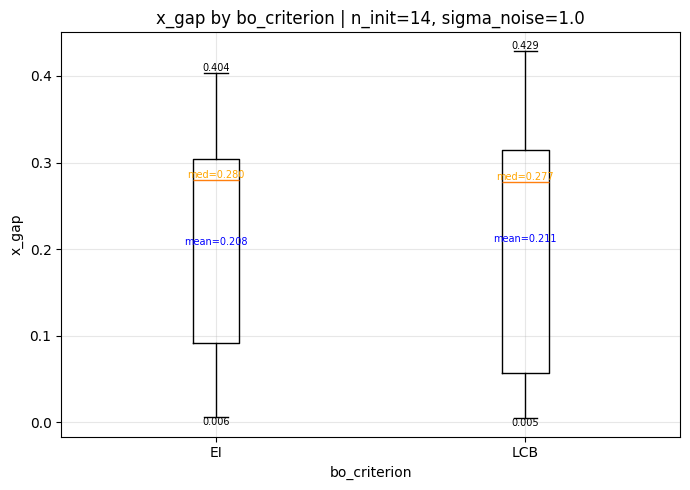

In [29]:
# x_gap group by bo_criterion
for n_init in [2, 6, 10, 14]:
    for sigma_noise in [0.1, 1.0]:
        plot_boxplot(
            results = res,
            metric    = "x_gap",
            group_by  = "bo_criterion",
            filters   = {
                "n_init": n_init,
                "sigma_noise": sigma_noise,
            },
        )

### **Boxplots y_gap group by bo_criterion.**

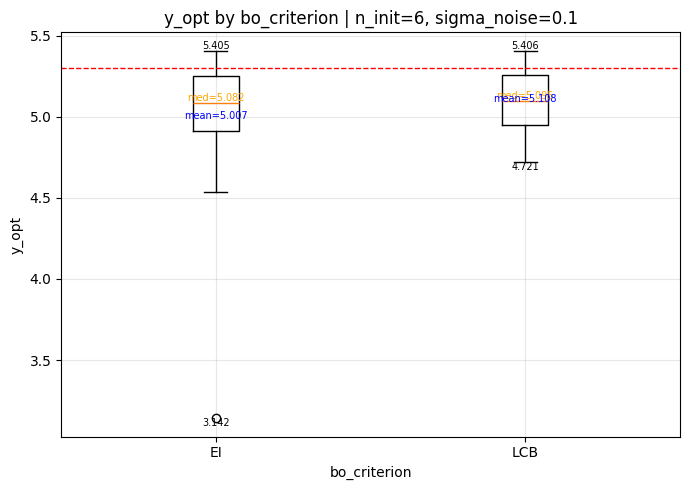

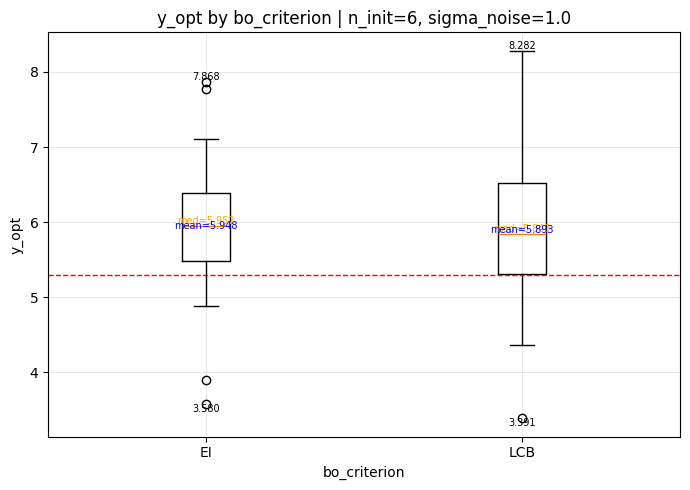

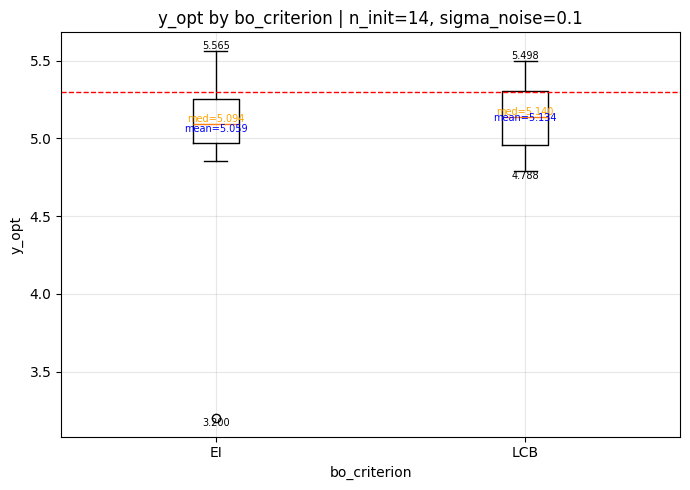

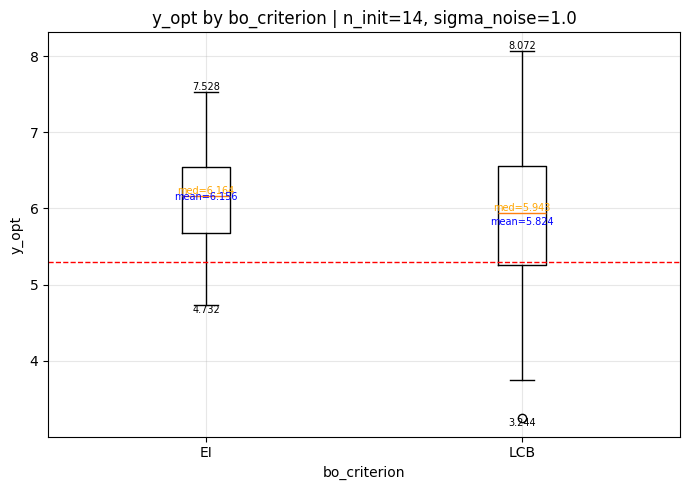

In [30]:
# y_gap group by bo_criterion
for n_init in [6, 14]:
    for sigma_noise in [0.1, 1.0]:
        plot_boxplot(
            results = res,
            metric    = "y_opt",
            group_by  = "bo_criterion",
            filters   = {
                "n_init": n_init,
                "sigma_noise": sigma_noise,
            },
        )

## **Investigate best/worst results.**

In [ ]:
def investigate_doe(results: List[dict], filters: dict = None, top_k: int = 5) -> None:
    if filters:
        results = filter_results(results, filters)

    if not results:
        print("No results found after filter was applied.")
        return

    # trier par y_gap croissant
    sorted_results = sorted(results, key=lambda r: r["y_gap"])
    best  = sorted_results[:top_k]
    worst = sorted_results[-top_k:]

    for label, group in [("BEST", best), ("WORST", worst)]:
        print(f"\n--- {label} {top_k} runs ---")
        for r in group:
            x_init = np.array(r["x_init"])
            y_init = np.array(r["y_init"]).ravel()
            x_data = np.array(r["x_data"])
            y_data = np.array(r["y_data"]).ravel()
            n_init = r["hyperparams"]["n_init"]

            # distribution qualitative du doe
            categ_counts = {}
            for x in x_init:
                key = (int(x[0]), int(x[1]))
                categ_counts[key] = categ_counts.get(key, 0) + 1

            print(f"\n  seed={r['seed']} | y_opt={r['y_opt']:.3f} | y_gap={r['y_gap']:.3f} | x_gap={r['x_gap']:.3f}")
            print(f"  DoE y_init : min={y_init.min():.3f}, max={y_init.max():.3f}, mean={y_init.mean():.3f}")
            print(f"  Distribution qualitative DoE : {categ_counts}")
            print(f"  Meilleur point DoE : y={y_init.max():.3f}")
            print(f"  Meilleur point BO  : y={y_data[n_init:].max():.3f}")
            print(f"  Convergence iter bo  : {calc_convergence_iter_bo(y_data=y_data, n_init=n_init)}")

In [34]:
def summarize_results(results: List[dict], filters: dict = None) -> None:
    if filters:
        results = filter_results(results, filters)

    if not results:
        print("No results found after filter was applied.")
        return
    
    y_gaps = [r["y_gap"] for r in results]
    x_gaps = [r["x_gap"] for r in results]
    y_opts = [r["y_opt"] for r in results]
    conv_iters = [calc_convergence_iter_bo(y_data=r['y_data'], n_init=r["hyperparams"]["n_init"]) for r in results]

    # taux de bons y_gap selon un seuil
    epsilon = 0.5
    n_success = sum(1 for g in y_gaps if g < epsilon)

    print(f"N runs={len(results)}")
    print(f"y_gap mean={np.mean(y_gaps):.3f}, std={np.std(y_gaps):.3f}, min={np.min(y_gaps):.3f}, max={np.max(y_gaps):.3f}")
    print(f"x_gap mean={np.mean(x_gaps):.3f}, std={np.std(x_gaps):.3f}, min={np.min(x_gaps):.3f}, max={np.max(x_gaps):.3f}")
    print(f"y_opt mean={np.mean(y_opts):.3f}, std={np.std(y_opts):.3f}")
    print(f"conv_iter_bo mean={np.mean(conv_iters):.1f}, std={np.std(conv_iters):.1f}, min={np.min(conv_iters)}, max={np.max(conv_iters)}")
    print(f"Taux succes (y_gap < {epsilon}) : {n_success}/{len(results)} = {100*n_success/len(results):.1f}%")

    # correlations
    print(f"\nCorrelation y_gap vs conv_iter_bo: {np.corrcoef(y_gaps, conv_iters)[0,1]:.3f}")
    print(f"Correlation y_gap vs y_init_max: {np.corrcoef(y_gaps, [np.array(r['y_init']).max() for r in results])[0,1]:.3f}")

In [35]:
summarize_results(res)
investigate_doe(res, top_k=5)

N runs=480
y_gap mean=0.595, std=0.616, min=0.001, max=3.218
x_gap mean=0.208, std=0.139, min=0.000, max=0.468
y_opt mean=5.471, std=0.839
conv_iter_bo mean=13.1, std=7.8, min=-10, max=28
Taux succes (y_gap < 0.5) : 303/480 = 63.1%

Correlation y_gap vs conv_iter_bo: -0.022
Correlation y_gap vs y_init_max: 0.029

--- BEST 5 runs ---

  seed=10 | y_opt=5.300 | y_gap=0.001 | x_gap=0.119
  DoE y_init : min=-2.137, max=-0.558, mean=-1.347
  Distribution qualitative DoE : {(0, 1): 1, (1, 0): 1}
  Meilleur point DoE : y=-0.558
  Meilleur point BO  : y=5.300
  Convergence iter bo  : 8

  seed=7 | y_opt=5.297 | y_gap=0.002 | x_gap=0.112
  DoE y_init : min=-4.933, max=4.476, mean=-0.660
  Distribution qualitative DoE : {(1, 0): 4, (1, 1): 3, (0, 1): 3, (0, 0): 4}
  Meilleur point DoE : y=4.476
  Meilleur point BO  : y=5.297
  Convergence iter bo  : 7

  seed=18 | y_opt=5.296 | y_gap=0.003 | x_gap=0.121
  DoE y_init : min=-3.724, max=0.063, mean=-1.922
  Distribution qualitative DoE : {(1, 1): 2